In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten,Conv2D,MaxPooling2D
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np

In [8]:
(train_images,train_labels),(test_images,test_labels)=mnist.load_data()


In [10]:
train_images=train_images.reshape(train_images.shape[0],28,28,1)
test_images=test_images.reshape(test_images.shape[0],28,28,1) #dataaugmentation

In [12]:
train_images=train_images/255.0
test_images=test_images/255.0 #normalization

In [30]:
#create model
model=Sequential()
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))

model.add(MaxPooling2D(2,2))
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))

model.add(MaxPooling2D(2,2))
model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dense(128,activation='softmax'))

In [32]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       102,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,608 (502.38 KB)

 Trainable params: 128,608 (502.38 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [36]:
model.fit(train_images,train_labels,epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9435 - loss: 0.1952
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9826 - loss: 0.0555
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9880 - loss: 0.0387
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9911 - loss: 0.0287
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9927 - loss: 0.0233


In [38]:
model.evaluate(test_images,test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9859 - loss: 0.0419


[0.04190514609217644, 0.9858999848365784]

In [40]:
classification=model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


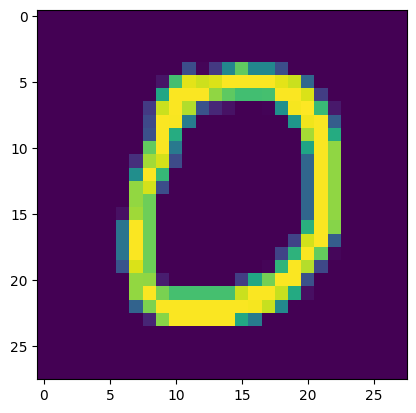

In [50]:
plt.imshow(test_images[10])

In [52]:
print(np.argmax(classification[10]))

0


In [56]:
from PIL import Image
import cv2
size=28,28
image1="digital2.jpg"
im=Image.open(image1)
im_resized=im.resize(size,Image.ANTIAlIAS)
im_resized.save("down.png")

img=cv2.imread("down.png")
img=img/255
img=np.reshape(img,(1,28,28,1))
prediction.model=predict(img)

print(np.argmax(prediction))

FileNotFoundError: [Errno 2] No such file or directory: '/Users/samruddhipowar5gmail.com/digital2.jpg'

In [58]:
plt.imshow(im)

NameError: name 'im' is not defined

In [60]:
model.save("digitalModel1.h5")

In [62]:
model.save_weights("DigitalModelWeights.h5")


ValueError: The filename must end in `.weights.h5`. Received: filepath=DigitalModelWeights.h5

In [64]:
new_model=load_model('digitalModel1.h5')


NameError: name 'load_model' is not defined

In [66]:
new_model=load_model('DigitalModelWeights.h5')

NameError: name 'load_model' is not defined